In [ ]:
!pip install -U -q PyDrive

In [ ]:
!gdown 1wpvbxGzzX1m0lcsnUXOAPd_vAE08URbN -O loan-clean-version.csv

Downloading...
From: https://drive.google.com/uc?id=1wpvbxGzzX1m0lcsnUXOAPd_vAE08URbN
To: /content/loan-clean-version.csv
100% 41.5M/41.5M [00:00<00:00, 117MB/s]


In [ ]:
import pandas as pd
import numpy as np

from tabulate import tabulate


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)


credit_df = pd.read_csv(
    'loan-clean-version.csv',
    skiprows=1,
    low_memory=False
)

credit_df.head()

display(credit_df.head())

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount
0,NaN,NaN,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
credit_df.describe()


,member_id,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,url,dti,delinq_2yrs,inq_last_6mths,...,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount
count,0.0,42535.000000,42535.000000,42535.000000,42535.000000,4.253100e+04,0.0,42535.000000,42506.000000,42506.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,11089.722581,10821.585753,10139.830603,322.623063,6.913656e+04,NaN,13.373043,0.152449,1.081424,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,7410.938391,7146.914675,7131.686447,208.927216,6.409635e+04,NaN,6.726315,0.512406,1.527455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,500.000000,500.000000,0.000000,15.670000,1.896000e+03,NaN,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,5200.000000,5000.000000,4950.000000,165.520000,4.000000e+04,NaN,8.200000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,9700.000000,9600.000000,8500.000000,277.690000,5.900000e+04,NaN,13.470000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,15000.000000,15000.000000,14000.000000,428.180000,8.250000e+04,NaN,18.680000,0.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,35000.000000,35000.000000,35000.000000,1305.190000,6.000000e+06,NaN,29.990000,13.000000,33.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
credit_df.shape

(42538, 137)

In [ ]:
credit_df.dtypes.value_counts()

,count
float64,112
object,25


In [ ]:
missing_ratio = credit_df.isnull().mean().sort_values(ascending=False)

missing_ratio.head(30)

,0
member_id,1.0
total_bal_il,1.0
mths_since_rcnt_il,1.0
open_il_24m,1.0
open_il_12m,1.0
open_il_6m,1.0
open_acc_6m,1.0
tot_cur_bal,1.0
url,1.0
hardship_payoff_balance_amount,1.0


In [ ]:
all_missing_cols = credit_df.columns[credit_df.isnull().mean() == 1]

print(len(all_missing_cols))
print(all_missing_cols.tolist())

81
['member_id', 'url', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',

In [ ]:
credit_df = credit_df.drop(columns=all_missing_cols)

In [ ]:
credit_df.shape

(42538, 56)

In [ ]:
credit_df[credit_df['loan_amnt'].isna()]

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag
39786,Loans that do not meet the credit policy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42536,Total amount funded in policy code 1: 460296150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42537,Total amount funded in policy code 2: 0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
credit_df = credit_df.dropna(subset=['loan_amnt'])

In [ ]:
credit_df.shape

(42535, 56)

In [ ]:
missing_ratio = credit_df.isnull().mean().sort_values(ascending=False)
missing_ratio.head(20)

,0
id,1.000000
next_pymnt_d,0.935371
mths_since_last_record,0.914165
mths_since_last_delinq,0.633032
desc,0.312566
emp_title,0.061737
pub_rec_bankruptcies,0.032091
emp_length,0.026143
chargeoff_within_12_mths,0.003409
collections_12_mths_ex_med,0.003409


In [ ]:
drop_cols = [
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'last_credit_pull_d',
    'hardship_flag',
    'funded_amnt',
    'funded_amnt_inv',
    'title',
    'zip_code',
    'pymnt_plan',
    'policy_code'
]

credit_df = credit_df.drop(columns=drop_cols)

credit_df.shape

(42535, 37)

In [ ]:
credit_df.columns.tolist()

['id',
 'loan_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'desc',
 'purpose',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'next_pymnt_d',
 'collections_12_mths_ex_med',
 'application_type',
 'acc_now_delinq',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'pub_rec_bankruptcies',
 'tax_liens']

In [ ]:
leakage_cols = [
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'last_credit_pull_d',
    'hardship_flag'
]

In [ ]:
low_value_cols = [
    'funded_amnt',
    'funded_amnt_inv',
    'title',
    'zip_code',
    'pymnt_plan',
    'policy_code'
]

In [ ]:
target = 'loan_status'

In [ ]:
feature_cols = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'issue_d',
    'purpose',
    'addr_state',
    'dti',
    'delinq_2yrs',
    'earliest_cr_line',
    'inq_last_6mths',
    'mths_since_last_delinq',
    'mths_since_last_record',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'initial_list_status',
    'collections_12_mths_ex_med',
    'application_type',
    'acc_now_delinq',
    'chargeoff_within_12_mths',
    'delinq_amnt',
    'pub_rec_bankruptcies',
    'tax_liens'
]

In [ ]:
credit_df['loan_status'].value_counts(dropna=False)

,count
loan_status,
Fully Paid,34116
Charged Off,5670
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761


In [ ]:
credit_df.dtypes

,0
id,object
loan_amnt,float64
term,object
int_rate,object
installment,float64
grade,object
sub_grade,object
emp_title,object
emp_length,object
home_ownership,object


In [ ]:
credit_df = credit_df[
    credit_df['loan_status'].isin(['Fully Paid', 'Charged Off'])
].copy()

credit_df['loan_status'] = credit_df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

In [ ]:
print(credit_df.shape)
print(credit_df['loan_status'].value_counts())

(39786, 37)
loan_status
0    34116
1     5670
Name: count, dtype: int64


In [ ]:

credit_df = credit_df.drop(columns=[
    'id',
    'emp_title',
    'desc',
    'next_pymnt_d'
])

credit_df.shape

(39786, 33)

In [ ]:
credit_df['term'] = (
    credit_df['term']
    .str.strip()
    .str.replace(' months', '', regex=False)
    .astype(int)
)

credit_df['int_rate'] = (
    credit_df['int_rate']
    .str.strip()
    .str.replace('%', '', regex=False)
    .astype(float)
)

credit_df['revol_util'] = (
    credit_df['revol_util']
    .str.strip()
    .str.replace('%', '', regex=False)
    .astype(float)
)

In [ ]:
credit_df[['term', 'int_rate', 'revol_util']].head()

,term,int_rate,revol_util
0,36,10.65,83.7
1,60,15.27,9.4
2,36,15.96,98.5
3,36,13.49,21.0
4,60,12.69,53.9


In [ ]:
credit_df[['term', 'int_rate', 'revol_util']].dtypes

,0
term,int64
int_rate,float64
revol_util,float64


In [ ]:
credit_df['issue_d'] = pd.to_datetime(
    credit_df['issue_d'],
    format='%b-%Y'
)

credit_df['earliest_cr_line'] = pd.to_datetime(
    credit_df['earliest_cr_line'],
    format='%b-%Y'
)

In [ ]:
credit_df = credit_df.drop(columns=[
    'issue_d',
    'earliest_cr_line'
])

In [ ]:
num_cols = credit_df.select_dtypes(include=np.number).columns
credit_df[num_cols] = credit_df[num_cols].fillna(credit_df[num_cols].median())

cat_cols = credit_df.select_dtypes(include='object').columns
credit_df[cat_cols] = credit_df[cat_cols].fillna('Unknown')

In [ ]:
credit_df.isnull().sum().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = credit_df.select_dtypes(include='object').columns

for col in cat_cols:
    encoder = LabelEncoder()
    credit_df[col] = encoder.fit_transform(credit_df[col].astype(str))

In [ ]:
credit_df.dtypes


,0
loan_amnt,float64
term,int64
int_rate,float64
installment,float64
grade,int64
sub_grade,int64
emp_length,int64
home_ownership,int64
annual_inc,float64
verification_status,int64


In [ ]:
from sklearn.model_selection import train_test_split

X = credit_df.drop('loan_status', axis=1)
y = credit_df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(29839, 30)
(9947, 30)
loan_status
0    25587
1     4252
Name: count, dtype: int64
loan_status
0    8529
1    1418
Name: count, dtype: int64


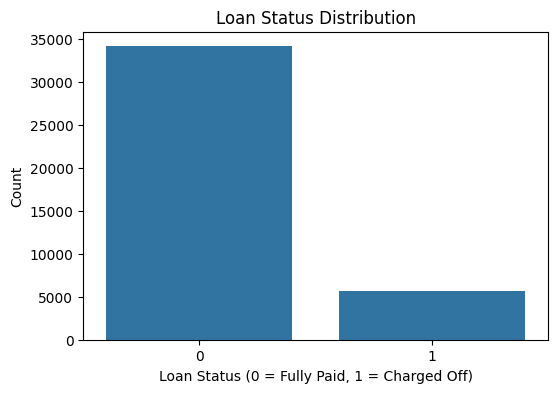

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x='loan_status', data=credit_df)

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (0 = Fully Paid, 1 = Charged Off)')
plt.ylabel('Count')

plt.show()

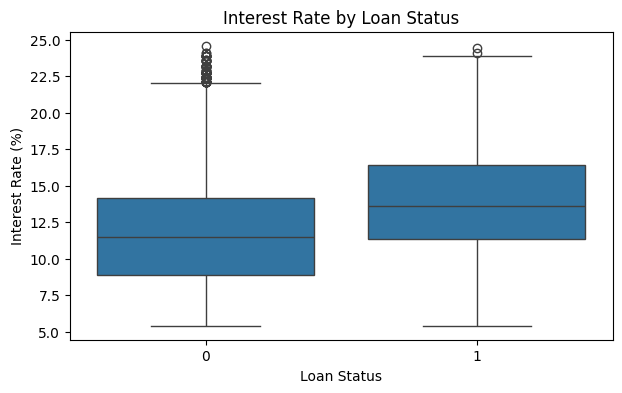

In [ ]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    x='loan_status',
    y='int_rate',
    data=credit_df
)

plt.title('Interest Rate by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Interest Rate (%)')

plt.show()

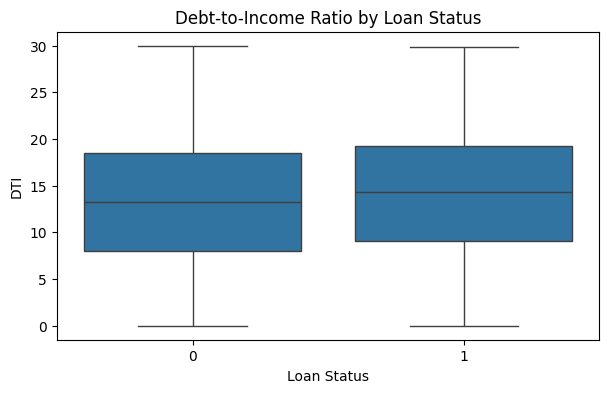

In [ ]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    x='loan_status',
    y='dti',
    data=credit_df
)

plt.title('Debt-to-Income Ratio by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('DTI')

plt.show()

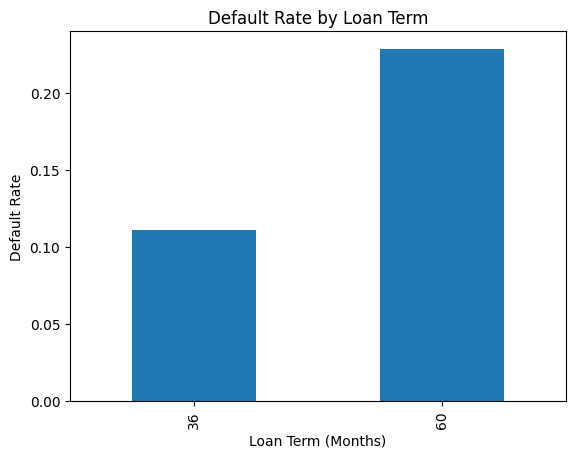

In [ ]:
default_by_term = credit_df.groupby('term')['loan_status'].mean()

default_by_term.plot(kind='bar')

plt.title('Default Rate by Loan Term')
plt.xlabel('Loan Term (Months)')
plt.ylabel('Default Rate')

plt.show()

**Logistic Regression baseline**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[8521    8]
 [1411    7]]
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      8529
           1       0.47      0.00      0.01      1418

    accuracy                           0.86      9947
   macro avg       0.66      0.50      0.47      9947
weighted avg       0.80      0.86      0.79      9947



**ROC-AUC**

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression AUC:", auc_log)

Logistic Regression AUC: 0.697855123340082


In [ ]:
log_model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = log_model_balanced.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

[[5493 3036]
 [ 508  910]]
              precision    recall  f1-score   support

           0       0.92      0.64      0.76      8529
           1       0.23      0.64      0.34      1418

    accuracy                           0.64      9947
   macro avg       0.57      0.64      0.55      9947
weighted avg       0.82      0.64      0.70      9947



In [ ]:
y_prob_balanced = log_model_balanced.predict_proba(X_test_scaled)[:, 1]

auc_balanced = roc_auc_score(y_test, y_prob_balanced)

print("Balanced Logistic Regression AUC:", auc_balanced)

Balanced Logistic Regression AUC: 0.6970730078628279


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[8526    3]
 [1416    2]]
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      8529
           1       0.40      0.00      0.00      1418

    accuracy                           0.86      9947
   macro avg       0.63      0.50      0.46      9947
weighted avg       0.79      0.86      0.79      9947



In [ ]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.6943482131236975


**Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

[[8520    9]
 [1406   12]]
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      8529
           1       0.57      0.01      0.02      1418

    accuracy                           0.86      9947
   macro avg       0.71      0.50      0.47      9947
weighted avg       0.82      0.86      0.79      9947



In [ ]:
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting AUC:", auc_gb)

Gradient Boosting AUC: 0.7071692347737191


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
2,int_rate,0.261704
8,annual_inc,0.140627
5,sub_grade,0.120968
1,term,0.104162
10,purpose,0.053152
20,revol_util,0.050977
14,inq_last_6mths,0.039845
3,installment,0.029745
11,addr_state,0.028156
19,revol_bal,0.027874


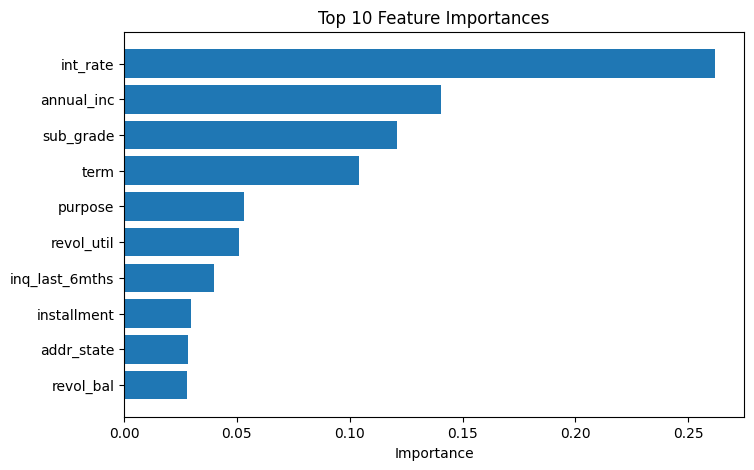

In [ ]:
import matplotlib.pyplot as plt

top10 = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10['Feature'], top10['Importance'])
plt.gca().invert_yaxis()

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')

plt.show()